# Week 8 Technical Analysis

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 1. Load and clean the COMPAS data

In [ ]:
path = "/content/compas-scores-two-years.csv"
df = pd.read_csv(path)

df_clean = df[
    df["days_b_screening_arrest"].between(-30, 30, inclusive="both")
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"] != "N/A")
].copy()

df_clean["high_risk"] = np.where(df_clean["score_text"] == "Low", 0, 1)

df_bw = df_clean[df_clean["race"].isin(["African-American", "Caucasian"])].copy()
df_bw["race_binary"] = np.where(df_bw["race"] == "African-American", 1, 0)

print("Clean sample size:", len(df_clean))
print("Black/White subsample size:", len(df_bw))
print("\nRace counts:")
print(df_bw["race"].value_counts())

Clean sample size: 6172
Black/White subsample size: 5278

Race counts:
race
African-American    3175
Caucasian           2103
Name: count, dtype: int64


## 2. Direction A: crime-type patterns in high-risk labeling

In [ ]:
top_n = 10
top_charge_types = df_clean["c_charge_desc"].value_counts().head(top_n).index.tolist()

df_top = df_clean[df_clean["c_charge_desc"].isin(top_charge_types)].copy()
df_top_bw = df_top[df_top["race"].isin(["African-American", "Caucasian"])].copy()

crime_summary = (
    df_top.groupby("c_charge_desc")
    .agg(
        n=("id", "count"),
        high_risk_rate=("high_risk", "mean"),
        actual_recid_rate=("two_year_recid", "mean"),
        avg_decile_score=("decile_score", "mean"),
        avg_priors=("priors_count", "mean"),
        avg_age=("age", "mean"),
    )
    .reset_index()
)
crime_summary["risk_minus_recid_gap"] = crime_summary["high_risk_rate"] - crime_summary["actual_recid_rate"]
crime_summary = crime_summary.sort_values("risk_minus_recid_gap", ascending=False).reset_index(drop=True)
crime_summary

,c_charge_desc,n,high_risk_rate,actual_recid_rate,avg_decile_score,avg_priors,avg_age,risk_minus_recid_gap
0,arrest case no charge,784,0.5217,0.4515,4.8202,4.6033,34.5561,0.0702
1,Grand Theft (Motor Vehicle),92,0.5978,0.5435,5.6957,3.3370,30.9457,0.0543
2,Pos Cannabis W/Intent Sel/Del,93,0.5484,0.5054,5.1720,2.6022,27.9355,0.0430
3,Grand Theft in the 3rd Degree,384,0.5052,0.4766,4.8385,2.1224,31.6328,0.0286
4,Driving While License Revoked,189,0.5556,0.5397,5.1481,7.8836,35.5714,0.0159
5,Possession of Cocaine,419,0.5919,0.5895,5.4821,5.0286,37.9618,0.0024
6,Battery,1087,0.3008,0.3707,3.4526,1.9218,35.0193,-0.0699
7,Felony Battery (Dom Strang),92,0.2391,0.3804,2.9891,1.8043,35.2500,-0.1413
8,Driving Under The Influence,126,0.0714,0.2619,2.1349,1.3175,41.8333,-0.1905
9,Felony Driving While Lic Suspd,93,0.3656,0.5591,3.5914,4.9892,38.3011,-0.1935


In [ ]:
crime_race_summary = (
    df_top_bw.groupby(["c_charge_desc", "race"])
    .agg(
        n=("id", "count"),
        high_risk_rate=("high_risk", "mean"),
        actual_recid_rate=("two_year_recid", "mean"),
        avg_decile_score=("decile_score", "mean"),
    )
    .reset_index()
)
crime_race_summary["risk_minus_recid_gap"] = crime_race_summary["high_risk_rate"] - crime_race_summary["actual_recid_rate"]
crime_race_summary.sort_values(["c_charge_desc", "race"]).reset_index(drop=True)

,c_charge_desc,race,n,high_risk_rate,actual_recid_rate,avg_decile_score,risk_minus_recid_gap
0,Battery,African-American,482,0.4253,0.4585,4.3133,-0.0332
1,Battery,Caucasian,405,0.2444,0.3160,3.0099,-0.0716
2,Driving Under The Influence,African-American,23,0.0870,0.3478,2.5217,-0.2609
3,Driving Under The Influence,Caucasian,85,0.0706,0.2824,1.9412,-0.2118
4,Driving While License Revoked,African-American,127,0.6220,0.5827,5.4961,0.0394
5,Driving While License Revoked,Caucasian,38,0.4474,0.4211,4.2632,0.0263
6,Felony Battery (Dom Strang),African-American,42,0.3571,0.3571,3.5238,0.0000
7,Felony Battery (Dom Strang),Caucasian,29,0.1034,0.4138,2.4138,-0.3103
8,Felony Driving While Lic Suspd,African-American,70,0.4286,0.5571,4.0286,-0.1286
9,Felony Driving While Lic Suspd,Caucasian,13,0.2308,0.3846,2.3846,-0.1538


## 3. Direction B: logistic regression for high-risk labeling

In [ ]:
df_pred = df_clean.copy()
df_pred["charge_group"] = np.where(
    df_pred["c_charge_desc"].isin(top_charge_types),
    df_pred["c_charge_desc"],
    "Other",
)

df_bw_pred = df_pred[df_pred["race"].isin(["African-American", "Caucasian"])].copy()
df_bw_pred["race_binary"] = np.where(df_bw_pred["race"] == "African-American", 1, 0)

model_pred = smf.logit(
    formula="""
    high_risk ~ race_binary
               + age
               + C(sex)
               + priors_count
               + C(c_charge_degree)
               + C(charge_group)
               + two_year_recid
    """,
    data=df_bw_pred,
).fit(disp=False)

print(model_pred.summary())

                           Logit Regression Results                           
Dep. Variable:              high_risk   No. Observations:                 5278
Model:                          Logit   Df Residuals:                     5261
Method:                           MLE   Df Model:                           16
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                  0.2796
Time:                        03:01:12   Log-Likelihood:                -2632.0
converged:                       True   LL-Null:                       -3653.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                             1.3005      0.189      6.873      0.000       0.930       1.671
C(sex)[T.Male]

In [ ]:
or_table_pred = pd.DataFrame({
    "variable": model_pred.params.index,
    "coef": model_pred.params.values,
    "odds_ratio": np.exp(model_pred.params.values),
    "p_value": model_pred.pvalues.values,
}).sort_values("odds_ratio", ascending=False).reset_index(drop=True)

or_table_pred

,variable,coef,odds_ratio,p_value
0,Intercept,1.3005,3.6713,0.0000
1,C(charge_group)[T.Possession of Cocaine],0.8892,2.4333,0.0000
2,C(charge_group)[T.Grand Theft (Motor Vehicle)],0.8648,2.3746,0.0041
3,two_year_recid,0.6329,1.8830,0.0000
4,C(charge_group)[T.Grand Theft in the 3rd Degree],0.5021,1.6522,0.0055
5,C(charge_group)[T.Pos Cannabis W/Intent Sel/Del],0.4940,1.6388,0.0759
6,race_binary,0.4453,1.5609,0.0000
7,C(charge_group)[T.Other],0.3999,1.4917,0.0008
8,C(charge_group)[T.arrest case no charge],0.3201,1.3773,0.0353
9,priors_count,0.2781,1.3206,0.0000


## 4. Direction C: random forest feature importance

In [ ]:
df_ml = df_clean.copy()
df_ml["charge_group"] = np.where(
    df_ml["c_charge_desc"].isin(top_charge_types),
    df_ml["c_charge_desc"],
    "Other",
)
df_ml = df_ml[df_ml["race"].isin(["African-American", "Caucasian"])].copy()

X = df_ml[["race", "sex", "age", "priors_count", "c_charge_degree", "charge_group", "two_year_recid"]]
y = df_ml["high_risk"]

categorical_features = ["race", "sex", "c_charge_degree", "charge_group"]
numeric_features = ["age", "priors_count", "two_year_recid"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42, max_depth=8)),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

Accuracy: 0.7544
AUC: 0.8458


In [ ]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)

feat_imp.head(20)

,feature,importance
0,num__priors_count,0.3289
1,num__age,0.2889
2,num__two_year_recid,0.1484
3,cat__race_Caucasian,0.0500
4,cat__race_African-American,0.0498
5,cat__c_charge_degree_F,0.0185
6,cat__c_charge_degree_M,0.0168
7,cat__sex_Male,0.0116
8,cat__charge_group_Battery,0.0114
9,cat__sex_Female,0.0105


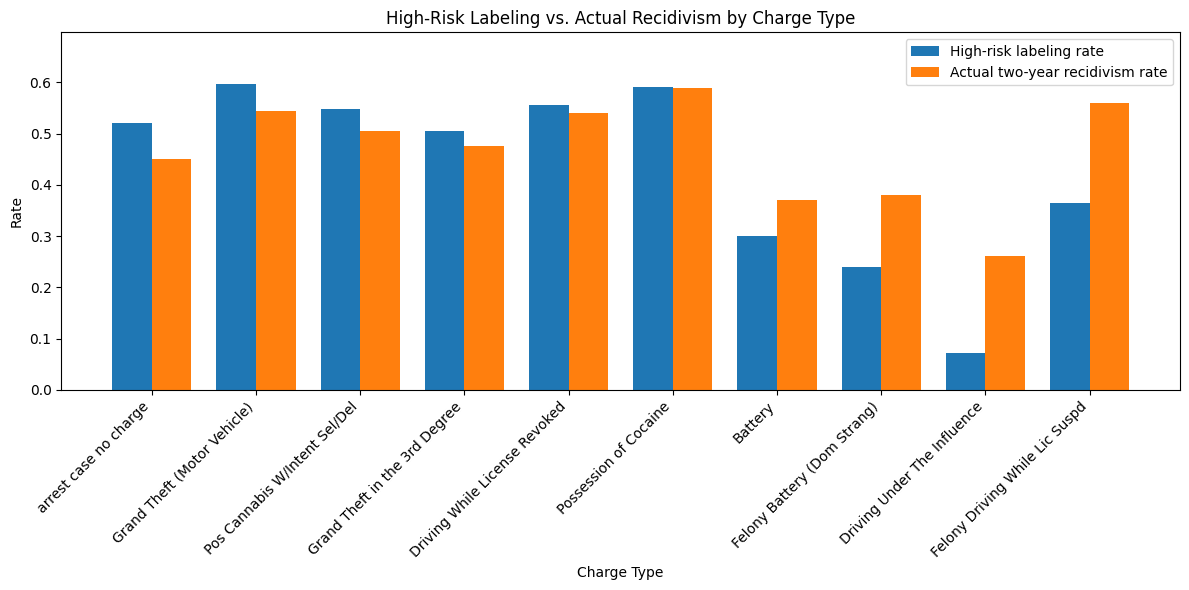

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plot_df1 = crime_summary.copy().sort_values("risk_minus_recid_gap", ascending=False)

x = np.arange(len(plot_df1))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, plot_df1["high_risk_rate"], width, label="High-risk labeling rate")
plt.bar(x + width/2, plot_df1["actual_recid_rate"], width, label="Actual two-year recidivism rate")

plt.xticks(x, plot_df1["c_charge_desc"], rotation=45, ha="right")
plt.ylabel("Rate")
plt.xlabel("Charge Type")
plt.title("Medium-High-Risk Labeling vs. Actual Recidivism by Charge Type")
plt.ylim(0, max(plot_df1["high_risk_rate"].max(), plot_df1["actual_recid_rate"].max()) + 0.1)
plt.legend()
plt.tight_layout()
plt.show()

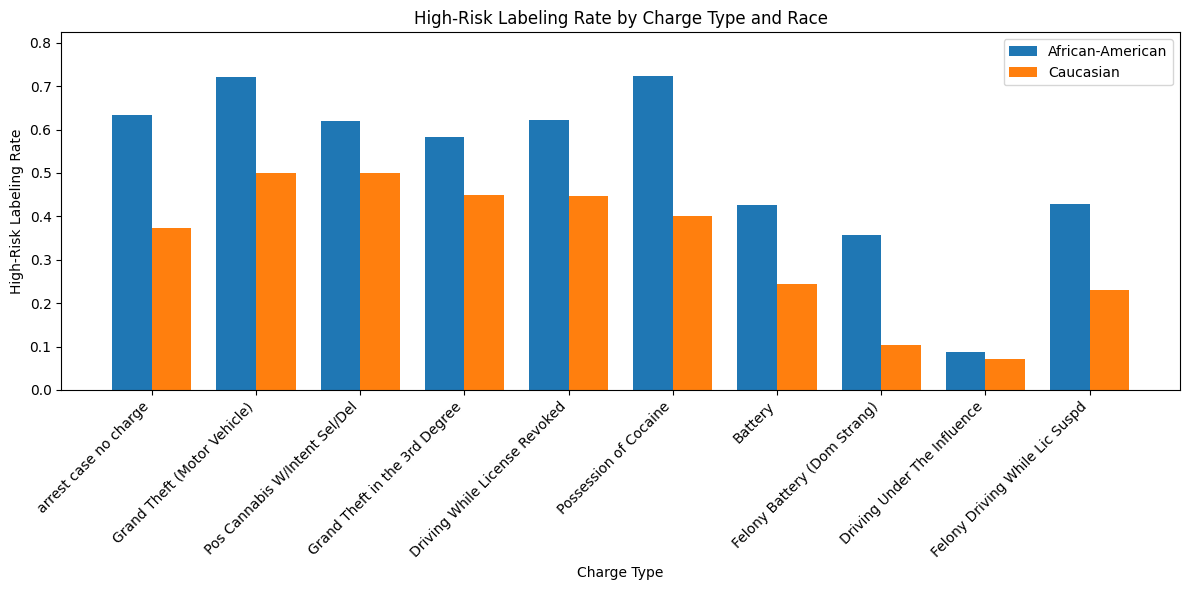

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plot_df2 = crime_race_summary.copy()

charge_order = crime_summary.sort_values("risk_minus_recid_gap", ascending=False)["c_charge_desc"].tolist()
plot_df2["c_charge_desc"] = pd.Categorical(plot_df2["c_charge_desc"], categories=charge_order, ordered=True)
plot_df2 = plot_df2.sort_values(["c_charge_desc", "race"])

pivot_df2 = plot_df2.pivot(index="c_charge_desc", columns="race", values="high_risk_rate")

x = np.arange(len(pivot_df2))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, pivot_df2["African-American"], width, label="African-American")
plt.bar(x + width/2, pivot_df2["Caucasian"], width, label="Caucasian")

plt.xticks(x, pivot_df2.index, rotation=45, ha="right")
plt.ylabel("High-Risk Labeling Rate")
plt.xlabel("Charge Type")
plt.title("Medium-High-Risk Labeling Rate by Charge Type and Race")
plt.ylim(0, max(pivot_df2.max()) + 0.1)
plt.legend()
plt.tight_layout()
plt.show()

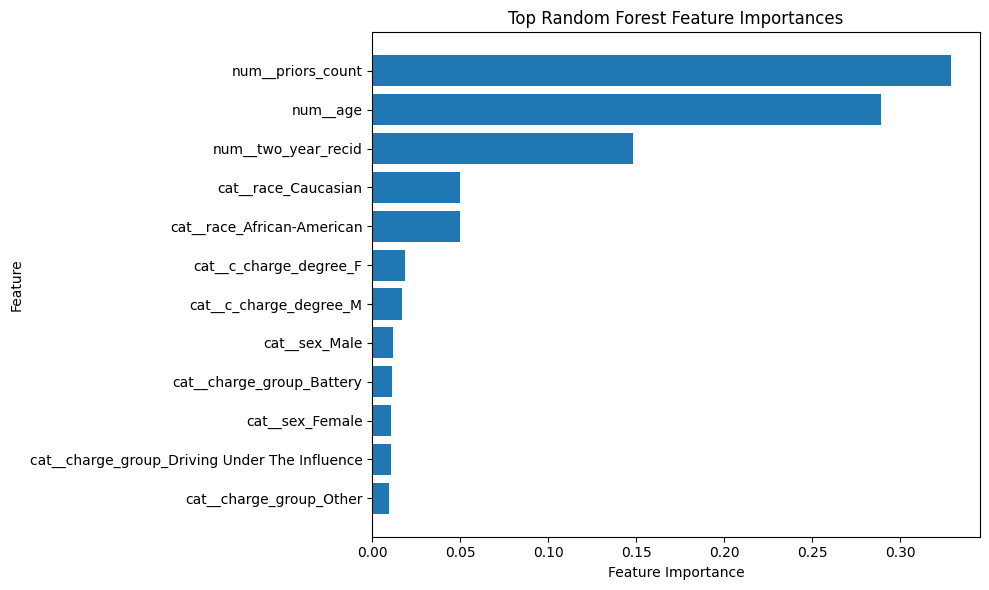

In [14]:
import matplotlib.pyplot as plt

plot_df3 = feat_imp.head(12).copy().sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df3["feature"], plot_df3["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()